# Fourth-order Childs--Schubert--Mendl comparison

This notebook compares two error-bound constructions for the **same merged fourth-order Suzuki formula**. It uses the repository's validated APIs and then counts the transpiled Clifford+T resources selected by each bound.

- **Childs general proof relaxation:** a concrete higher-order relaxation of the commutator-scaling proof.
- **Schubert--Mendl centered bound:** Theorem 1 evaluated at the conventional center of the same Suzuki factor sequence.
- **Childs Appendix M:** an optional fourth-order consistency check; for the two-group case it agrees with Schubert--Mendl at the corresponding center.

The comparison keeps the Hamiltonian grouping, factor ordering, merged exponentials, norm convention, order, evolution time, and target error explicit.

## 1. Setup and comparison convention

For one fourth-order step, both bounds have the form

\[\lVert S_4(\delta)-e^{-iH\delta}\rVert \le C_5|\delta|^5.\]

With `r` equal segments, the unitary telescoping bound is

\[\epsilon_{\mathrm{bound}}(r)=C_5|t|^5/r^4.\]

The primary comparison is Childs general relaxation versus Schubert--Mendl centered. Appendix M is retained as a diagnostic rather than treated as an independent improvement claim.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from hamiltonian_resources import (
    build_fourth_order_bound_problem,
    build_trotter_circuit,
    childs_fourth_order_small_prefactor_bound,
    childs_general_commutator_bound,
    count_circuit_resources,
    heisenberg_chain,
    schubert_mendl_small_prefactor_bound,
    transverse_field_ising,
)

ORDER = 4
TIME = 0.2
NORM_METHOD = "pauli-l1"
ROTATION_SYNTHESIS_ERROR = 1e-4
OPTIMIZATION_LEVEL = 1
SYSTEM_SIZE_POINTS = tuple(np.unique(np.round(np.geomspace(3, 200, 24)).astype(int)))
HEISENBERG_SYSTEM_SIZE_POINTS = tuple(np.unique(np.round(np.geomspace(3, 50, 16)).astype(int)))
TARGET_ERRORS = tuple(np.logspace(-2, -8, 13))
RESOURCE_TARGET_ERRORS = (1e-2, 3e-3, 1e-3)
BASE_QUBITS = 3

pd.set_option("display.max_columns", None)

## 2. Shared fourth-order problems

The comparison object is built once per Hamiltonian. Every evaluator receives that same object, so differences below come from the bound construction rather than from changing the product formula.

In [2]:
def model_cases(num_qubits):
    return {
        "TFIM": transverse_field_ising(num_qubits, coupling=1.0, field=0.7),
        "Heisenberg": heisenberg_chain(num_qubits, coupling=1.0, field_z=0.3),
    }

def compare_bound_methods(hamiltonian):
    problem = build_fourth_order_bound_problem(
        hamiltonian, partition="auto", merge_adjacent=True
    )
    results = {
        "Childs general": childs_general_commutator_bound(
            problem, norm_method=NORM_METHOD
        ),
        "Schubert--Mendl centered": schubert_mendl_small_prefactor_bound(
            problem, center=problem.centered_index, norm_method=NORM_METHOD
        ),
        "Childs Appendix M": childs_fourth_order_small_prefactor_bound(
            problem, norm_method=NORM_METHOD
        ),
    }
    return problem, results

base_problems = {}
base_results = {}
for name, hamiltonian in model_cases(BASE_QUBITS).items():
    base_problems[name], base_results[name] = compare_bound_methods(hamiltonian)
    problem = base_problems[name]
    print(
        f"{name}: groups={problem.group_count}, group_sizes={problem.group_sizes}, "
        f"merged exponentials={problem.exponential_count}, center s={problem.centered_index}"
    )

TFIM: groups=2, group_sizes=(2, 3), merged exponentials=11, center s=6
Heisenberg: groups=3, group_sizes=(4, 4, 1), merged exponentials=21, center s=11


In [3]:
def result_table(problem, results, target_error=1e-3):
    rows = []
    for method, result in results.items():
        required = (
            result.required_segments(TIME, target_error)
            if result.status == "ok"
            else None
        )
        rows.append({
            "method": method,
            "bound_family": result.bound_family,
            "C5": result.one_step_coefficient,
            "center_s": result.center_index,
            "required_segments": required,
            "status": result.status,
            "rigorous": result.rigorous,
        })
    return pd.DataFrame(rows)

for name in base_problems:
    print(name)
    display(result_table(base_problems[name], base_results[name]))

TFIM


,method,bound_family,C5,center_s,required_segments,status,rigorous
0,Childs general,childs-general-commutator,2.545237e+06,NaN,31,ok,True
1,Schubert--Mendl centered,schubert-mendl-small-prefactor,8.438238e+00,6.0,2,ok,True
2,Childs Appendix M,childs-fourth-order-small-prefactor,8.438238e+00,6.0,2,ok,True


Heisenberg


,method,bound_family,C5,center_s,required_segments,status,rigorous
0,Childs general,childs-general-commutator,3.159501e+07,NaN,57,ok,True
1,Schubert--Mendl centered,schubert-mendl-small-prefactor,1.330210e+02,11.0,3,ok,True
2,Childs Appendix M,childs-fourth-order-small-prefactor,1.415933e+02,10.0,3,ok,True


The general Childs curve is intentionally labeled a **proof relaxation**. Its large coefficient is not an exact numerical constant claimed by the asymptotic theorem; it reflects the explicit relaxation used by the implementation.

## 3. Fixed-repetition error comparison

At fixed `r`, the product formula is identical. Only the reported upper bound changes.

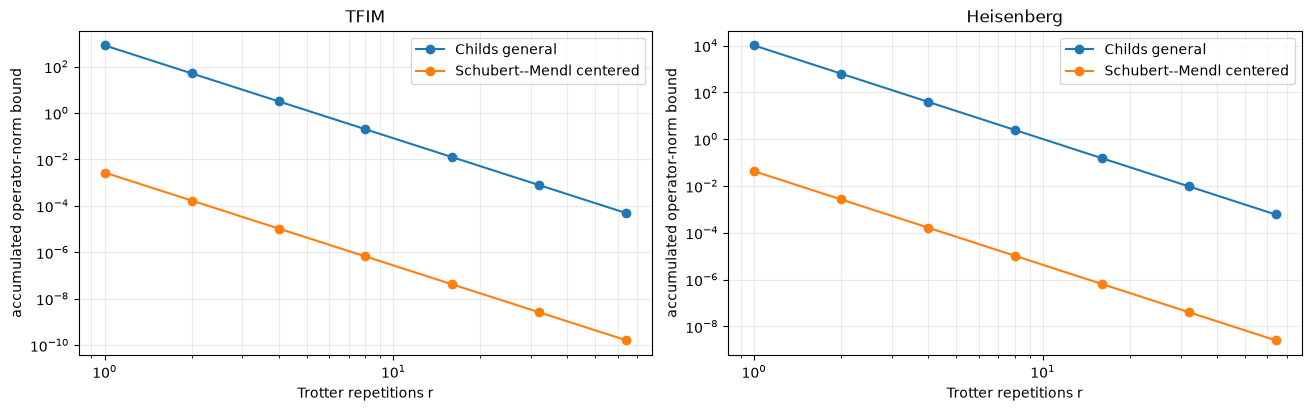

In [4]:
repetition_grid = np.array([1, 2, 4, 8, 16, 32, 64])
primary_methods = ("Childs general", "Schubert--Mendl centered")
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for ax, (name, results) in zip(axes, base_results.items()):
    for method in primary_methods:
        result = results[method]
        errors = [result.accumulated_error_bound(TIME, int(r)) for r in repetition_grid]
        ax.loglog(repetition_grid, errors, marker="o", label=method)
    ax.set_title(name)
    ax.set_xlabel("Trotter repetitions r")
    ax.set_ylabel("accumulated operator-norm bound")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
plt.show()

## 4. Bound sweeps over system size and target error

The TFIM size sweep uses 24 logarithmically spaced integer points from N=3 to N=200. The Heisenberg sweep stops at N=50 because its three-group exact sparse nested-commutator evaluation becomes very expensive at larger N; the target-error comparison still uses both models.

In [5]:
def bound_sweep(model_name, sizes, target_errors):
    rows = []
    for num_qubits in sizes:
        hamiltonian = model_cases(num_qubits)[model_name]
        problem, results = compare_bound_methods(hamiltonian)
        for target_error in target_errors:
            for method in primary_methods:
                result = results[method]
                repetitions = result.required_segments(TIME, target_error)
                rows.append({
                    "model": model_name,
                    "system_qubits": num_qubits,
                    "target_error": target_error,
                    "method": method,
                    "C5": result.one_step_coefficient,
                    "required_segments": repetitions,
                    "continuous_segments": (
                        result.one_step_coefficient * abs(TIME) ** 5 / target_error
                    ) ** 0.25,
                    "accumulated_bound": result.accumulated_error_bound(
                        TIME, repetitions
                    ),
                })
    return pd.DataFrame(rows)

size_frame = pd.concat(
    [bound_sweep("TFIM", SYSTEM_SIZE_POINTS, (1e-3,)),
     bound_sweep("Heisenberg", HEISENBERG_SYSTEM_SIZE_POINTS, (1e-3,))],
    ignore_index=True,
)
error_frame = pd.concat(
    [bound_sweep(name, (BASE_QUBITS,), TARGET_ERRORS) for name in ("TFIM", "Heisenberg")],
    ignore_index=True,
)
display(size_frame)
display(error_frame)

,model,system_qubits,target_error,method,C5,required_segments,continuous_segments,accumulated_bound
0,TFIM,3,0.001,Childs general,2.545237e+06,31,30.041358,0.000882
1,TFIM,3,0.001,Schubert--Mendl centered,8.438238e+00,2,1.281889,0.000169
2,TFIM,4,0.001,Childs general,4.769109e+06,36,35.147692,0.000909
3,TFIM,4,0.001,Schubert--Mendl centered,1.472399e+01,2,1.473309,0.000294
4,TFIM,5,0.001,Childs general,6.992981e+06,39,38.677027,0.000967
...,...,...,...,...,...,...,...,...
71,Heisenberg,34,0.001,Schubert--Mendl centered,1.750972e+04,9,8.651817,0.000854
72,Heisenberg,41,0.001,Childs general,6.670722e+09,215,214.946662,0.000999
73,Heisenberg,41,0.001,Schubert--Mendl centered,2.702073e+04,10,9.642991,0.000865
74,Heisenberg,50,0.001,Childs general,8.260482e+09,227,226.745587,0.000996


,model,system_qubits,target_error,method,C5,required_segments,continuous_segments,accumulated_bound
0,TFIM,3,1.000000e-02,Childs general,2.545237e+06,17,16.893497,9.751750e-03
1,TFIM,3,1.000000e-02,Schubert--Mendl centered,8.438238e+00,1,0.720859,2.700236e-03
2,TFIM,3,3.162278e-03,Childs general,2.545237e+06,23,22.527841,2.910495e-03
3,TFIM,3,3.162278e-03,Schubert--Mendl centered,8.438238e+00,1,0.961281,2.700236e-03
4,TFIM,3,1.000000e-03,Childs general,2.545237e+06,31,30.041358,8.819247e-04
5,TFIM,3,1.000000e-03,Schubert--Mendl centered,8.438238e+00,2,1.281889,1.687648e-04
6,TFIM,3,3.162278e-04,Childs general,2.545237e+06,41,40.060795,2.882324e-04
7,TFIM,3,3.162278e-04,Schubert--Mendl centered,8.438238e+00,2,1.709427,1.687648e-04
8,TFIM,3,1.000000e-04,Childs general,2.545237e+06,54,53.421929,9.578626e-05
9,TFIM,3,1.000000e-04,Schubert--Mendl centered,8.438238e+00,3,2.279557,3.333625e-05


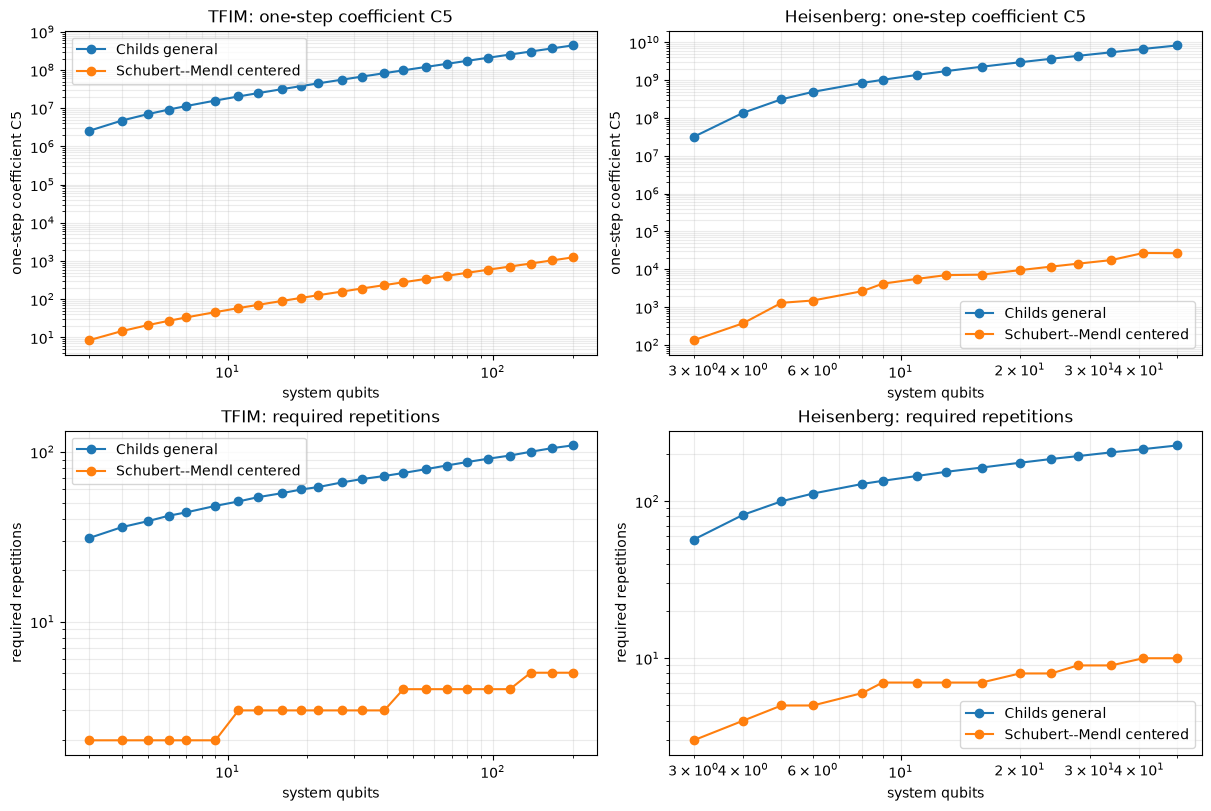

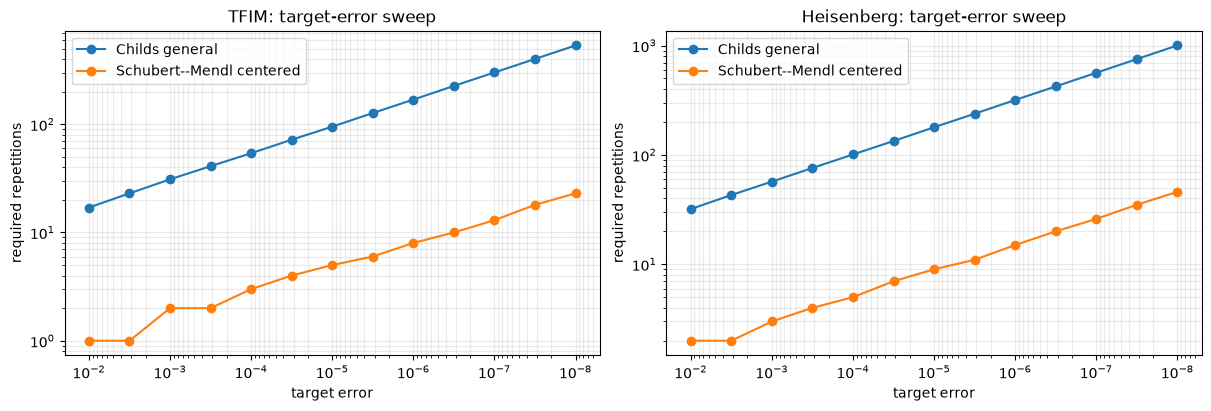

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for column, ylabel, row in (("C5", "one-step coefficient C5", 0), ("required_segments", "required repetitions", 1)):
    for col, model_name in enumerate(("TFIM", "Heisenberg")):
        ax = axes[row, col]
        subset = size_frame[size_frame.model == model_name]
        for method in primary_methods:
            curve = subset[subset.method == method]
            ax.loglog(curve.system_qubits, curve[column], marker="o", label=method)
        ax.set_title(f"{model_name}: {ylabel}")
        ax.set_xlabel("system qubits")
        ax.set_ylabel(ylabel)
        ax.grid(True, which="both", alpha=0.25)
        ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, model_name in zip(axes, ("TFIM", "Heisenberg")):
    subset = error_frame[error_frame.model == model_name]
    for method in primary_methods:
        curve = subset[subset.method == method].sort_values("target_error")
        ax.loglog(curve.target_error, curve.required_segments, marker="o", label=method)
    ax.set_title(f"{model_name}: target-error sweep")
    ax.set_xlabel("target error")
    ax.set_ylabel("required repetitions")
    ax.invert_xaxis()
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
plt.show()

,model,method,slope_C5_vs_N,slope_continuous_segments_vs_N,slope_continuous_segments_vs_epsilon
0,TFIM,Childs general,1.153679,0.288420,-0.25
1,TFIM,Schubert--Mendl centered,1.131401,0.282850,-0.25
2,Heisenberg,Childs general,1.710338,0.427584,-0.25
3,Heisenberg,Schubert--Mendl centered,1.684553,0.421138,-0.25


Expected epsilon slope for a fourth-order bound: -1/4 = -0.25


method,system_qubits,Childs general,Schubert--Mendl centered,C5_ratio_Childs_over_Schubert,model,sweep,target_error
0,3.0,2.545237e+06,8.438238,301631.364971,TFIM,system_qubits,NaN
1,4.0,4.769109e+06,14.723994,323900.527415,TFIM,system_qubits,NaN
2,5.0,6.992981e+06,21.009749,332844.589420,TFIM,system_qubits,NaN
3,6.0,9.216853e+06,27.295505,337669.278130,TFIM,system_qubits,NaN
4,7.0,1.144073e+07,33.581260,340687.792012,TFIM,system_qubits,NaN
...,...,...,...,...,...,...,...
59,NaN,3.159501e+07,133.021010,237518.929405,Heisenberg,target_error,0.000100
60,NaN,3.159501e+07,133.021010,237518.929405,Heisenberg,target_error,0.000316
61,NaN,3.159501e+07,133.021010,237518.929405,Heisenberg,target_error,0.001000
62,NaN,3.159501e+07,133.021010,237518.929405,Heisenberg,target_error,0.003162


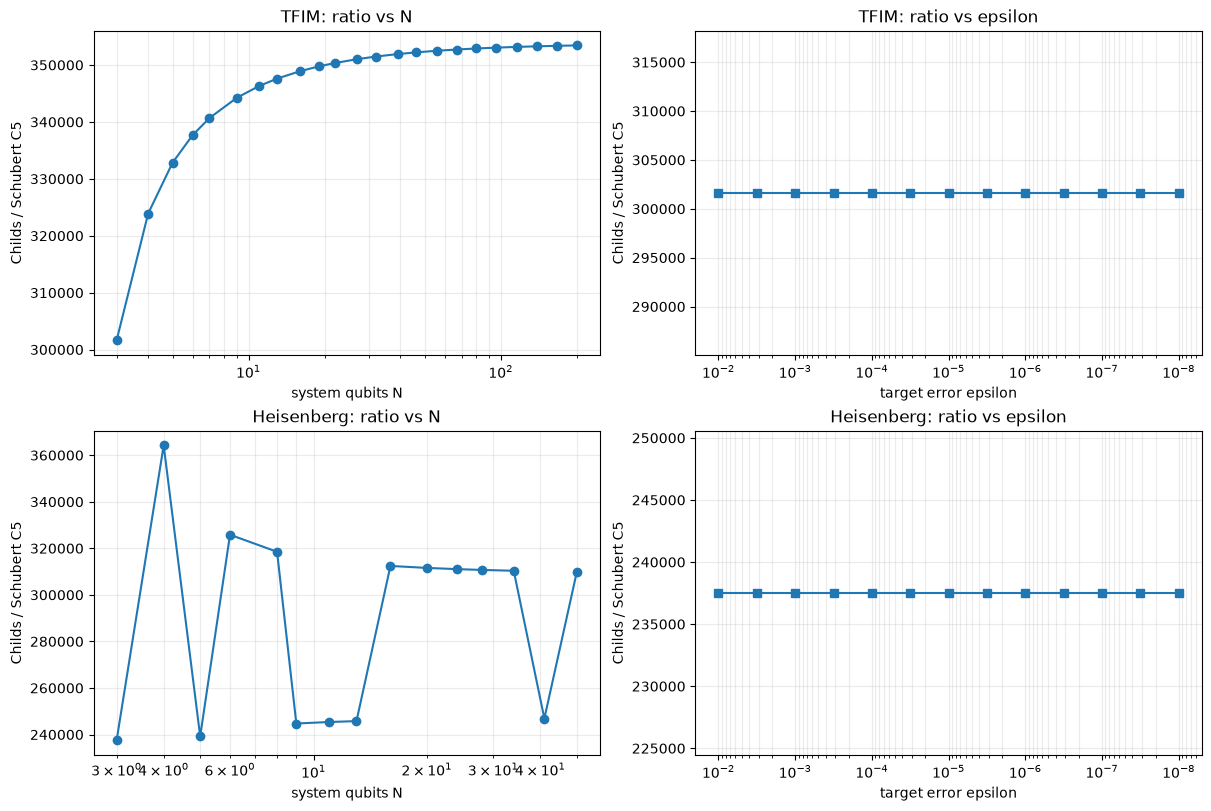

In [7]:
def loglog_slope(frame, x_column, y_column, method):
    curve = frame[frame.method == method].sort_values(x_column)
    return float(np.polyfit(np.log(curve[x_column]), np.log(curve[y_column]), 1)[0])

slope_rows = []
for model_name in ("TFIM", "Heisenberg"):
    for method in primary_methods:
        size_curve = size_frame[size_frame.model == model_name]
        error_curve = error_frame[error_frame.model == model_name]
        slope_rows.append({
            "model": model_name,
            "method": method,
            "slope_C5_vs_N": loglog_slope(size_curve, "system_qubits", "C5", method),
            "slope_continuous_segments_vs_N": loglog_slope(size_curve, "system_qubits", "continuous_segments", method),
            "slope_continuous_segments_vs_epsilon": loglog_slope(error_curve, "target_error", "continuous_segments", method),
        })
slope_frame = pd.DataFrame(slope_rows)
display(slope_frame)
print("Expected epsilon slope for a fourth-order bound: -1/4 = -0.25")

ratio_rows = []
for model_name in ("TFIM", "Heisenberg"):
    for source_frame, x_column in ((size_frame, "system_qubits"), (error_frame, "target_error")):
        subset = source_frame[source_frame.model == model_name]
        pivot = subset.pivot(index=x_column, columns="method", values="C5").reset_index()
        pivot["C5_ratio_Childs_over_Schubert"] = pivot["Childs general"] / pivot["Schubert--Mendl centered"]
        pivot["model"] = model_name
        pivot["sweep"] = x_column
        ratio_rows.append(pivot)
ratio_frame = pd.concat(ratio_rows, ignore_index=True)
display(ratio_frame)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for row, model_name in enumerate(("TFIM", "Heisenberg")):
    size_ratio = ratio_frame[(ratio_frame.model == model_name) & (ratio_frame.sweep == "system_qubits")].sort_values("system_qubits")
    error_ratio = ratio_frame[(ratio_frame.model == model_name) & (ratio_frame.sweep == "target_error")].sort_values("target_error")
    axes[row, 0].semilogx(size_ratio.system_qubits, size_ratio.C5_ratio_Childs_over_Schubert, marker="o")
    axes[row, 0].set_title(f"{model_name}: ratio vs N")
    axes[row, 0].set_xlabel("system qubits N")
    axes[row, 0].set_ylabel("Childs / Schubert C5")
    axes[row, 0].grid(True, which="both", alpha=0.25)
    axes[row, 1].semilogx(error_ratio.target_error, error_ratio.C5_ratio_Childs_over_Schubert, marker="s")
    axes[row, 1].set_title(f"{model_name}: ratio vs epsilon")
    axes[row, 1].set_xlabel("target error epsilon")
    axes[row, 1].set_ylabel("Childs / Schubert C5")
    axes[row, 1].invert_xaxis()
    axes[row, 1].grid(True, which="both", alpha=0.25)
plt.show()

## Interpretation of the scaling results

For both methods, the fourth-order accumulated bound has the same functional form

\[r_{\min}=\left\lceil\left(C_5|t|^5/\epsilon\right)^{1/4}\right\rceil.\]

The staircase visible in the integer repetition plots is caused by the ceiling function: the number of Trotter repetitions must be an integer. It is not evidence that Schubert--Mendl uses a different asymptotic order. The continuous-repetition curves remove this rounding effect.

At fixed system size, both methods therefore have the same target-error exponent,

\[r\propto\epsilon^{-1/4}.\]

The ratio of the continuous repetition counts is

\[\frac{r_{\mathrm{Childs}}}{r_{\mathrm{SM}}} \approx \left(\frac{C_5^{\mathrm{Childs}}}{C_5^{\mathrm{SM}}}\right)^{1/4}.\]

Integer repetition ratios fluctuate around this value because of rounding. For the TFIM example at `N=3`, the notebook obtains approximately `C5_Childs = 2.55e6` and `C5_SM = 8.44`, a prefactor ratio of about `3.0e5` and a continuous repetition ratio of about `23.4`. At `target_error=1e-3`, this appears as roughly 31 Childs repetitions versus 2 Schubert--Mendl repetitions.

The two methods are strictly equivalent up to a constant factor only if the `C5` ratio approaches a constant as `N` grows. The ratio plots test this directly. In the TFIM sweep, the ratio is approximately `3.0e5` at small `N` and approximately `3.5e5` near `N=200`: this is broadly constant but has finite-size drift, reflecting different commutator over-counting and proof relaxations.

If both prefactors scale as `C5 ~ N^a`, then

\[r\sim N^{a/4}\epsilon^{-1/4}.\]

Since one fourth-order Suzuki repetition has a circuit cost that is approximately linear in `N` for these local chains, the resulting T and CNOT counts are expected to scale roughly as `N^{1+a/4}` at fixed error. Thus a constant prefactor difference changes the vertical position of the resource curves, while a different fitted `N` exponent changes their asymptotic slope.

## 5. Appendix-M consistency check

For the two-group TFIM decomposition, Childs Appendix M uses center `s=6` in the 11-exponential merged formula. Schubert--Mendl evaluated at the same center should reproduce it term-for-term and in total.

In [8]:
tfim_problem = base_problems["TFIM"]
appendix = base_results["TFIM"]["Childs Appendix M"]
schubert_s6 = schubert_mendl_small_prefactor_bound(
    tfim_problem, center=6, norm_method=NORM_METHOD
)

print("merged exponentials:", tfim_problem.exponential_count)
print("Appendix M C5:", appendix.one_step_coefficient)
print("Schubert s=6 C5:", schubert_s6.one_step_coefficient)
assert tfim_problem.exponential_count == 11
assert np.isclose(appendix.one_step_coefficient, schubert_s6.one_step_coefficient)

merged exponentials: 11
Appendix M C5: 8.438238289913093
Schubert s=6 C5: 8.438238289913093


## 6. Method-specific transpiled T and CNOT counts

The resource sweep uses the repetitions selected by each bound independently. It counts transpiled `cx` gates and estimates Clifford+T cost for the resulting `rz` rotations. The sweep is intentionally small because the Childs general relaxation can require many more repetitions than the Schubert--Mendl bound.

In [9]:
def resource_sweep(model_name, sizes=(3,), target_errors=RESOURCE_TARGET_ERRORS):
    rows = []
    for num_qubits in sizes:
        hamiltonian = model_cases(num_qubits)[model_name]
        problem, results = compare_bound_methods(hamiltonian)
        for target_error in target_errors:
            algorithm_error = target_error - ROTATION_SYNTHESIS_ERROR
            if algorithm_error <= 0:
                raise ValueError("target error must exceed synthesis error")
            for method in primary_methods:
                bound_result = results[method]
                repetitions = bound_result.required_segments(TIME, algorithm_error)
                circuit = build_trotter_circuit(
                    hamiltonian,
                    TIME,
                    repetitions,
                    ORDER,
                    partition="auto",
                )
                resource = count_circuit_resources(
                    circuit,
                    algorithm=method,
                    total_synthesis_error=ROTATION_SYNTHESIS_ERROR,
                    optimization_level=OPTIMIZATION_LEVEL,
                )
                row = resource.as_dict()
                row.update(
                    model=model_name,
                    method=method,
                    system_qubits=num_qubits,
                    target_error=target_error,
                    repetitions=repetitions,
                    bound_C5=bound_result.one_step_coefficient,
                )
                rows.append(row)
    return pd.DataFrame(rows)

resource_frame = pd.concat(
    [resource_sweep(name) for name in ("TFIM", "Heisenberg")],
    ignore_index=True,
)
display(
    resource_frame[
        ["model", "target_error", "method", "repetitions", "t_count", "cnot_count", "rotation_count", "depth", "counting_mode"]
    ]
)

,model,target_error,method,repetitions,t_count,cnot_count,rotation_count,depth,counting_mode
0,TFIM,0.010,Childs general,17,43435,680,595,1445,transpiled
1,TFIM,0.010,Schubert--Mendl centered,1,2100,40,35,85,transpiled
2,TFIM,0.003,Childs general,24,62160,960,840,2040,transpiled
3,TFIM,0.003,Schubert--Mendl centered,1,2100,40,35,85,transpiled
4,TFIM,0.001,Childs general,31,81375,1240,1085,2635,transpiled
5,TFIM,0.001,Schubert--Mendl centered,2,4410,80,70,170,transpiled
6,Heisenberg,0.010,Childs general,32,189679,3840,2401,9600,transpiled
7,Heisenberg,0.010,Schubert--Mendl centered,2,9966,240,151,600,transpiled
8,Heisenberg,0.003,Childs general,44,264080,5280,3301,13200,transpiled
9,Heisenberg,0.003,Schubert--Mendl centered,2,9966,240,151,600,transpiled


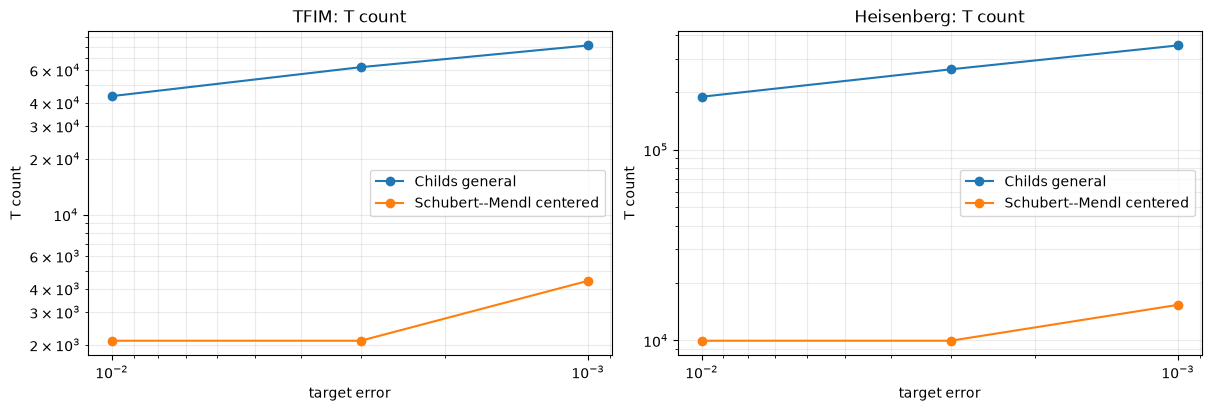

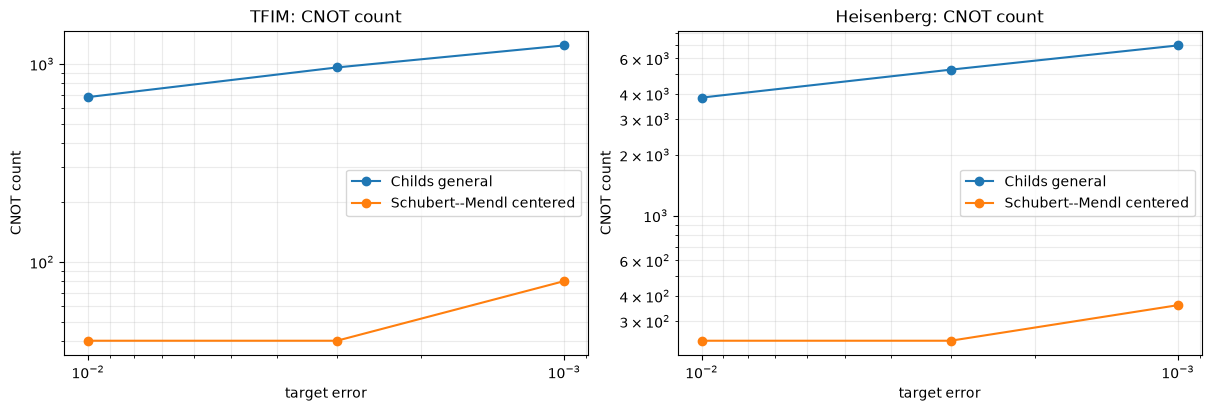

In [10]:
for metric, ylabel in (("t_count", "T count"), ("cnot_count", "CNOT count")):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    for ax, model_name in zip(axes, ("TFIM", "Heisenberg")):
        subset = resource_frame[resource_frame.model == model_name]
        for method in primary_methods:
            curve = subset[subset.method == method].sort_values("target_error")
            ax.loglog(curve.target_error, curve[metric], marker="o", label=method)
        ax.set_title(f"{model_name}: {ylabel}")
        ax.set_xlabel("target error")
        ax.set_ylabel(ylabel)
        ax.invert_xaxis()
        ax.grid(True, which="both", alpha=0.25)
        ax.legend()
    plt.show()

## 7. Validation checks

These checks verify that the comparison is using one common fourth-order formula and that each selected repetition count meets its own algorithmic error target.

In [11]:
for name, problem in base_problems.items():
    assert problem.order == ORDER
    assert problem.merged_consecutive
    for method in primary_methods:
        result = base_results[name][method]
        repetitions = result.required_segments(TIME, 9e-4)
        assert result.status == "ok"
        assert result.rigorous
        assert result.accumulated_error_bound(TIME, repetitions) <= 9e-4
        if repetitions > 1:
            assert result.accumulated_error_bound(TIME, repetitions - 1) > 9e-4

assert (resource_frame.t_count > 0).all()
assert (resource_frame.cnot_count > 0).all()
assert set(resource_frame.counting_mode) == {"transpiled"}
print("All notebook validation checks passed.")

All notebook validation checks passed.


## References

- A. M. Childs, Y. Su, M. C. Tran, N. Wiebe, and S. Zhu, [A Theory of Trotter Error](https://arxiv.org/abs/1912.08854).
- A. Schubert and C. B. Mendl, [Trotter error with commutator scaling for the Fermi-Hubbard model](https://arxiv.org/abs/2306.10603).
- Repository implementation notes: [`docs/fourth_order_bound_comparison.md`](../docs/fourth_order_bound_comparison.md).